In [89]:
import pandas as pd
import nltk
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [90]:
df = pd.read_csv('labeledTrainData.tsv', sep='\t')
df.head()

,id,sentiment,review
0,5814_8,1,With all this stuff going down at the moment w...
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hi..."
2,7759_3,0,The film starts with a manager (Nicholas Bell)...
3,3630_4,0,It must be assumed that those who praised this...
4,9495_8,1,Superbly trashy and wondrously unpretentious 8...


In [91]:
%%time
def preprocess(df):
    df['review'] = df.review.str.lower()
    df['document_sentences'] = df.review.str.split('.')
    df['tokenized_sentences'] = list(map(lambda sentences: list(map(nltk.word_tokenize, sentences)), df.document_sentences))
    df['tokenized_sentences'] = list(map(lambda sentences: list(filter(lambda lst: lst, sentences)), df.tokenized_sentences))
preprocess(df)

CPU times: total: 22.8 s
Wall time: 22.8 s


In [92]:
from sklearn.model_selection import train_test_split
train, test, y_train, y_test = train_test_split(df.drop(columns='sentiment'), df['sentiment'], test_size=0.2)

In [93]:
voc = []
for sen in train.tokenized_sentences:
    voc.extend(sen)
print('len(voc) = ', len(voc))
print("len(train) = ", len(train))

len(voc) =  250152
len(train) =  20000


In [94]:
from gensim.models import word2vec, Word2Vec

num_features = 300
min_word_count = 3
num_workers = 4
context = 8
downsampling = 1e-3

W2WModel = Word2Vec(sentences=voc, sg=1, hs=0, workers=num_workers, min_count=min_word_count, window=context, sample=downsampling, negative=5, vector_size=num_features, epochs=6)



In [95]:
def sentence_vectors(model, sentences):
    words = np.concatenate(sentences)

    model_vocab = set(model.wv.key_to_index.keys())

    sent_vector = np.zeros(model.wv.vector_size, dtype='float32')
    n_words = 0

    for w in words:
        if w in model_vocab:
            sent_vector += model.wv[w]
            n_words += 1

    if n_words > 0:
        sent_vector /= n_words

    return sent_vector

train['sentence_vectors'] = list(map(lambda sen_group: sentence_vectors(W2WModel, sen_group), train.tokenized_sentences))

In [96]:
def vectors_to_feats(df, ndim):
    index = []
    for i in range(ndim):
        df[f'w2v_{i}'] = df['sentence_vectors'].apply(lambda x: x[i])
        index.append(f'w2v_{i}')
    return  df[index]

X_train = vectors_to_feats(train, 300)
X_train.head()

,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_290,w2v_291,w2v_292,w2v_293,w2v_294,w2v_295,w2v_296,w2v_297,w2v_298,w2v_299
5260,-0.046258,0.223105,0.098807,0.033184,0.086296,-0.073461,0.119897,0.225340,0.044177,0.005969,...,0.044923,0.147901,0.072449,0.036203,0.135146,0.091638,0.031617,-0.101140,-0.019173,-0.022306
2460,-0.028417,0.169623,0.025580,0.002692,0.030359,-0.057764,0.096918,0.215295,-0.007407,-0.005224,...,0.083556,0.145973,0.051067,0.041143,0.197818,0.148517,0.026227,-0.133837,0.025656,-0.021544
12619,-0.043269,0.177237,0.036770,0.017387,0.056916,-0.087671,0.135636,0.202551,0.012226,0.033020,...,0.042322,0.163137,0.044741,0.038013,0.148977,0.123069,0.003856,-0.109969,0.099034,-0.059935
4536,-0.015148,0.193481,0.039021,-0.002413,0.052787,-0.059642,0.126364,0.216993,0.000948,-0.001741,...,0.085608,0.129608,0.053737,0.024711,0.156722,0.145490,0.039161,-0.134174,0.048476,-0.068405
18900,-0.005917,0.173694,0.007025,0.025134,-0.009321,-0.060299,0.127090,0.199038,-0.006955,0.011653,...,0.056051,0.146437,0.064849,0.029664,0.203131,0.114154,0.035850,-0.117309,0.039623,-0.015661


In [97]:
test['sentence_vectors'] = list(map(lambda sen_group: sentence_vectors(W2WModel, sen_group), test.tokenized_sentences))
X_test = vectors_to_feats(test, 300)

In [98]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [99]:
from sklearn.metrics import roc_auc_score, confusion_matrix
roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

0.9412928501249695

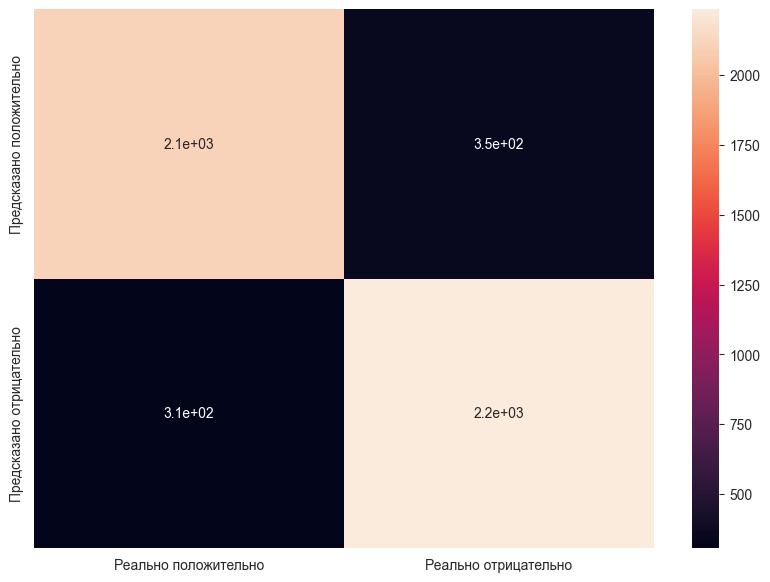

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

df_cm = pd.DataFrame(confusion_matrix(y_test, lr.predict(X_test)),
                     index=["Предсказано положительно", "Предсказано отрицательно"],
                     columns=["Реально положительно", "Реально отрицательно"])
plt.figure(figsize = (10, 7))
sns.heatmap(data=df_cm, annot=True)
plt.show()

In [101]:
voc_df = []
for sen in df.tokenized_sentences:
    voc_df.extend(sen)

print(len(voc_df))
print(len(df))

313267
25000


In [102]:
%%time
W2WModel = Word2Vec(sentences=voc_df, sg=1, hs=0, workers=num_workers, min_count=min_word_count, window=context, sample=downsampling, negative=5, vector_size=num_features, epochs=6)

CPU times: total: 5min 41s
Wall time: 1min 27s


In [103]:
df['sentence_vectors'] = list(map(lambda sen: sentence_vectors(W2WModel, sen), df.tokenized_sentences))
df = vectors_to_feats(df, 300)
y = pd.read_csv('labeledTrainData.tsv', sep='\t')['sentiment'].values

In [114]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(df, y)

from sklearn.model_selection import ShuffleSplit, cross_val_score
cv = ShuffleSplit(n_splits=5, random_state=1)
cv_score = cross_val_score(lr, df, y, cv=cv, scoring='roc_auc')
print(cv_score, cv_score.mean())


[0.93593695 0.93657912 0.93711026 0.93854962 0.93638646] 0.9369124807998395


In [115]:
def predict_sentiment(review_text, w2v_model, lr_model):
    review_lower = review_text.lower()

    sentences = review_lower.split('.')

    tokenized_sentences = [nltk.word_tokenize(sent) for sent in sentences]

    tokenized_sentences = [sent for sent in tokenized_sentences if sent]

    review_vector = sentence_vectors(w2v_model, tokenized_sentences)

    review_features = review_vector.reshape(1, -1)

    prediction = lr_model.predict(review_features)[0]
    probabilities = lr_model.predict_proba(review_features)[0]

    return prediction, probabilities


def analyze_review(review_text):
    prediction, probability = predict_sentiment(review_text, W2WModel, lr)

    print("="* 60)
    if prediction ==1:
        sentiment = 'positive'
    else:
        sentiment = 'negative'
    print("Sentiment:", sentiment)
    print("="* 60)
    print("probability:", probability)
    print(f"negative: {probability[0]:.2%}")
    print(f"positive: {probability[1]:.2%}")
    return prediction, probability


In [116]:
my_review = """I went into this movie with modest expectations, but it completely exceeded them. From the first scene, the film pulls you into its world with confident pacing, strong atmosphere, and a sense of emotional depth that only grows stronger as the story unfolds.

The performances are outstanding—every actor feels perfectly cast, bringing nuance and authenticity to their roles. The chemistry between the leads is especially compelling, making even the quieter moments feel meaningful.

Visually, the film is beautifully shot. The cinematography uses color and framing to enhance the themes without ever feeling forced. Combined with a thoughtful soundtrack, the overall tone becomes both immersive and memorable.

What impressed me most is the balance between entertainment and substance. The plot remains engaging throughout, but there’s also plenty to think about after the credits roll. It's the kind of movie that lingers in your mind long after watching.

In short, this is a film that deserves more attention. Whether you’re here for strong characters, emotional storytelling, or striking visuals, you’ll find something to love. Highly recommended."""

analyze_review(my_review)


Sentiment: positive
probability: [0.00886433 0.99113567]
negative: 0.89%
positive: 99.11%


(np.int64(1), array([0.00886433, 0.99113567]))

In [117]:
my_review = """I really wanted to like this movie, but unfortunately it falls short in almost every way. The story feels unfocused and drags on without any real sense of purpose. Scenes come and go without building momentum, and by the halfway point it becomes clear that the film doesn’t know what it wants to be.

The acting is inconsistent, ranging from passable to outright flat. Even talented cast members seem lost, as if they weren’t given proper direction. The dialogue doesn’t help either — it’s stiff, repetitive, and often unintentionally awkward.

Visually, the film is surprisingly bland. The cinematography lacks creativity, relying on generic shots that do nothing to enhance the mood or tone. The soundtrack is forgettable, and in some moments, even distracting.

The biggest issue, though, is the pacing. The film feels much longer than it actually is, with entire stretches where nothing meaningful happens. Instead of building tension or emotional stakes, it wastes time on scenes that add little to the plot or characters.

By the end, I felt more relieved than satisfied. It’s not the worst movie you’ll ever see, but it’s definitely one of the most disappointing — especially considering the potential it had. Not recommended unless you’re extremely curious."""
analyze_review(my_review)

Sentiment: negative
probability: [0.97427959 0.02572041]
negative: 97.43%
positive: 2.57%


(np.int64(0), array([0.97427959, 0.02572041]))